# Étape 4 : Stratégies de Train/Test Split

## Objectif

Créer une **configuration d'évaluation robuste** qui simule des scénarios réels pour les systèmes de recommandation.

## 🎯 Problématique

Le choix de la **stratégie de split** est **critique** pour évaluer correctement un système de recommandation :

❌ **Mauvais split** → Métriques trompeuses, modèle qui ne fonctionne pas en production
✅ **Bon split** → Évaluation réaliste, confiance dans les performances

## 📚 Stratégies à Comparer

Selon le projet (RecSys Project.docx) et la documentation LightFM ([Cross-validation](https://lyst.github.io/lightfm/docs/examples/cross_validation.html)), nous allons comparer **3 stratégies** :

### 1. **Split Temporel** (Temporal Split)
- **Principe** : Séparer les données selon le **temps**
- **Train** : Interactions anciennes (ex: 6 premiers mois)
- **Test** : Interactions récentes (ex: dernier mois)
- **Avantages** : ✅ Le plus réaliste (simule prédiction du futur)
- **Inconvénients** : ⚠️ Peut avoir du cold-start si nouveaux users/items dans test

### 2. **Split Aléatoire** (Random Split)
- **Principe** : Séparer **aléatoirement** les interactions de chaque user
- **Train** : 80% des interactions de chaque user
- **Test** : 20% des interactions de chaque user
- **Avantages** : ✅ Pas de cold-start, distribution équilibrée
- **Inconvénients** : ⚠️ Moins réaliste (data leakage temporel)
- **Implémentation** : `random_train_test_split()` de LightFM

### 3. **Split par Utilisateur** (User-based Split)
- **Principe** : Garder des **utilisateurs entiers** pour le test
- **Train** : 80% des users avec toutes leurs interactions
- **Test** : 20% des users avec toutes leurs interactions
- **Avantages** : ✅ Simule recommandation pour nouveaux users
- **Inconvénients** : ⚠️ Cold-start complet (très difficile)

## 📊 Plan d'Analyse

Pour chaque stratégie, nous allons :

1. **Implémenter** le split
2. **Analyser** les distributions (users, items, interactions, sparsité)
3. **Vérifier** le cold-start problem
4. **Entraîner** un modèle simple (BPR)
5. **Comparer** les performances
6. **Choisir** la meilleure stratégie pour notre cas d'usage

## ⚙️ Configuration : Choix de la Taille du Sample

### 🎯 Cohérence avec Step 3

**IMPORTANT** : Utilisez la **même taille** que dans Step 3 pour garantir la cohérence des données.

| Taille | Transactions | Users | Items | Usage |
|--------|-------------|-------|-------|-------|
| **10K** | ~10,000 | ~3K | ~2.5K | Debug rapide |
| **50K** | ~50,000 | ~12K | ~8K | **Expérimentation** ⭐ |
| **100K** | ~100,000 | ~20K | ~12K | Production |

**Modifiez `SAMPLE_SIZE` ci-dessous.**

In [1]:
# ⚙️ CONFIGURATION : Choisir la taille du sample
# Valeurs possibles : '10K', '50K', '100K'
# IMPORTANT: Utiliser la même taille que Step 3

SAMPLE_SIZE = '50K'  # ⭐ Recommandé pour expérimentation

print(f"{'='*80}")
print(f"CONFIGURATION")
print(f"{'='*80}")
print(f"\n✅ Taille sélectionnée : {SAMPLE_SIZE}")
print(f"   Chemin source : data/processed/{SAMPLE_SIZE}/")
print(f"   Chemin destination splits : data/processed/{SAMPLE_SIZE}/splits/")

# Vérifier que les données processed existent (Step 3 doit être terminé)
import os
processed_path = f'data/processed/{SAMPLE_SIZE}/'
if not os.path.exists(processed_path):
    print(f"\n❌ ERREUR: Le dossier {processed_path} n'existe pas!")
    print(f"   Exécutez d'abord Step 3 avec SAMPLE_SIZE = '{SAMPLE_SIZE}'")
    raise FileNotFoundError(f"Processed data {SAMPLE_SIZE} non trouvé")

# Vérifier fichiers essentiels
required_files = [
    'lightfm_dataset.pkl',
    'user_item_matrix.npz',
    'transactions.csv'
]

for file in required_files:
    if not os.path.exists(processed_path + file):
        print(f"\n❌ ERREUR: Fichier manquant : {file}")
        raise FileNotFoundError(f"{file} manquant dans {processed_path}")

print(f"\n✅ Configuration validée - Données Step 3 trouvées")

CONFIGURATION

✅ Taille sélectionnée : 50K
   Chemin source : data/processed/50K/
   Chemin destination splits : data/processed/50K/splits/

✅ Configuration validée - Données Step 3 trouvées


## 1. Configuration et Imports

In [2]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import json
import pickle
import os
import time

# Imports scipy
from scipy.sparse import load_npz, csr_matrix, coo_matrix

# Imports LightFM
try:
    from lightfm import LightFM
    from lightfm.evaluation import precision_at_k, recall_at_k, auc_score
    from lightfm.cross_validation import random_train_test_split
    from lightfm.data import Dataset
    LIGHTFM_AVAILABLE = True
    print("✅ LightFM installé et disponible")
except ImportError:
    LIGHTFM_AVAILABLE = False
    print("⚠️  LightFM n'est pas installé.")
    raise ImportError("LightFM est requis pour ce notebook")

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Seed
np.random.seed(42)

print("✅ Configuration terminée")

✅ LightFM installé et disponible
✅ Configuration terminée


/opt/anaconda3/envs/lightfm_env/lib/python3.10/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


## 2. Chargement des Données (Step 3)

### 📂 Source : Données Prétraitées

Nous chargeons les données **prétraitées** (Step 3) qui contiennent :
- ✅ Dataset LightFM avec mappings
- ✅ Matrice d'interactions complète
- ✅ Transactions DataFrame (nécessaire pour split temporel)

**Pourquoi depuis Step 3 ?**
- Les mappings user_id/item_id sont déjà créés
- Le Dataset LightFM est déjà fitted
- On peut directement créer les splits et matrices

In [3]:
print("=" * 80)
print(f"CHARGEMENT DES DONNÉES PRÉTRAITÉES (STEP 3 - {SAMPLE_SIZE})")
print("=" * 80)

import pickle
from scipy.sparse import load_npz

# Chemins
PROCESSED_DATA_PATH = f'data/processed/{SAMPLE_SIZE}/'
SPLITS_PATH = f'data/processed/{SAMPLE_SIZE}/splits/'
os.makedirs(SPLITS_PATH, exist_ok=True)

# 1. Charger Dataset LightFM
print("\n📂 Chargement du Dataset LightFM...")
with open(PROCESSED_DATA_PATH + 'lightfm_dataset.pkl', 'rb') as f:
    dataset = pickle.load(f)
print(f"   ✓ Dataset LightFM chargé")
print(f"   ✓ Dimensions: {dataset.interactions_shape()}")

# 2. Charger matrice d'interactions complète
print("\n📂 Chargement de la matrice d'interactions...")
full_interactions = load_npz(PROCESSED_DATA_PATH + 'user_item_matrix.npz')
print(f"   ✓ Matrice: {full_interactions.shape}")
print(f"   ✓ Interactions: {full_interactions.nnz:,}")

# 3. Charger transactions DataFrame (nécessaire pour split temporel)
print("\n📂 Chargement du DataFrame transactions...")
transactions = pd.read_csv(PROCESSED_DATA_PATH + 'transactions.csv')
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
print(f"   ✓ Transactions: {len(transactions):,}")

# 4. Charger métadonnées de preprocessing
with open(PROCESSED_DATA_PATH + 'preprocessing_metadata.json', 'r') as f:
    preprocessing_meta = json.load(f)

# Stats
num_users, num_items = dataset.interactions_shape()
n_interactions = full_interactions.nnz

print("\n" + "=" * 80)
print(f"📊 DATASET COMPLET ({SAMPLE_SIZE} - avant split)")
print("=" * 80)
print(f"   Users: {num_users:,}")
print(f"   Items: {num_items:,}")
print(f"   Interactions: {n_interactions:,}")
print(f"   Période: {transactions['t_dat'].min().date()} → {transactions['t_dat'].max().date()}")
print(f"   Durée: {(transactions['t_dat'].max() - transactions['t_dat'].min()).days} jours")

sparsity = 1 - (n_interactions / (num_users * num_items))
print(f"   Sparsité: {sparsity:.4%}")

print("\n✅ Données chargées - Prêt pour les 3 stratégies de split")

CHARGEMENT DES DONNÉES PRÉTRAITÉES (STEP 3 - 50K)

📂 Chargement du Dataset LightFM...
   ✓ Dataset LightFM chargé
   ✓ Dimensions: (46668, 24216)

📂 Chargement de la matrice d'interactions...
   ✓ Matrice: (46668, 24216)
   ✓ Interactions: 50,000

📂 Chargement du DataFrame transactions...
   ✓ Transactions: 50,000

📊 DATASET COMPLET (50K - avant split)
   Users: 46,668
   Items: 24,216
   Interactions: 50,000
   Période: 2018-09-20 → 2020-09-22
   Durée: 733 jours
   Sparsité: 99.9956%

✅ Données chargées - Prêt pour les 3 stratégies de split


## 3. Préparation du Dataset LightFM (Commun aux 3 Stratégies)

Avant de tester différentes stratégies de split, nous devons créer le Dataset LightFM avec les mappings.

**Note** : Nous utilisons le même Dataset pour les 3 stratégies pour garantir la cohérence des mappings.

In [4]:
print("=" * 80)
print("CHARGEMENT DU DATASET LIGHTFM DE STEP 3")
print("=" * 80)

# CRITIQUE : Charger le dataset de Step 3 au lieu de le recréer
# pour garantir que les mappings sont identiques

print(f"\n📂 Chargement du Dataset LightFM (Step 3)...")
with open(PROCESSED_DATA_PATH + 'lightfm_dataset.pkl', 'rb') as f:
    dataset = pickle.load(f)

print(f"   ✓ Dataset chargé depuis Step 3")

# Vérifier les dimensions
num_users, num_items = dataset.interactions_shape()
print(f"\n📊 Dimensions du Dataset:")
print(f"   Users: {num_users:,}")
print(f"   Items: {num_items:,}")

# Récupérer les IDs uniques depuis transactions
unique_users = transactions['customer_id'].unique()
unique_items = transactions['article_id'].unique()

print(f"\n📊 IDs uniques dans transactions:")
print(f"   Utilisateurs: {len(unique_users):,}")
print(f"   Articles: {len(unique_items):,}")

# Vérifier la cohérence
if len(unique_users) != num_users or len(unique_items) != num_items:
    print(f"\n⚠️  WARNING: Dimensions différentes !")
    print(f"   Dataset : {num_users} users, {num_items} items")
    print(f"   Transactions : {len(unique_users)} users, {len(unique_items)} items")
    print(f"   → Normal si filtrage dans Step 3")

# Construire la matrice complète avec le dataset de Step 3
print(f"\n🔄 Construction de la matrice d'interactions complète...")
(full_interactions, _) = dataset.build_interactions(
    ((row['customer_id'], row['article_id'])
     for idx, row in transactions.iterrows())
)

print(f"   ✓ Matrice complète: {full_interactions.shape}, {full_interactions.nnz:,} interactions")

print("\n✅ Dataset LightFM de Step 3 chargé - Mappings garantis identiques")
print("   ⚠️  IMPORTANT : Les splits utiliseront les mêmes mappings que Step 3")

CHARGEMENT DU DATASET LIGHTFM DE STEP 3

📂 Chargement du Dataset LightFM (Step 3)...
   ✓ Dataset chargé depuis Step 3

📊 Dimensions du Dataset:
   Users: 46,668
   Items: 24,216

📊 IDs uniques dans transactions:
   Utilisateurs: 46,668
   Articles: 24,216

🔄 Construction de la matrice d'interactions complète...
   ✓ Matrice complète: (46668, 24216), 50,000 interactions

✅ Dataset LightFM de Step 3 chargé - Mappings garantis identiques
   ⚠️  IMPORTANT : Les splits utiliseront les mêmes mappings que Step 3


## 4. Stratégie 1 : Split Temporel (Temporal Split)

### 📅 Principe

Séparer les données selon le **temps** :
- **Train** : 90% des transactions les plus anciennes
- **Test** : 10% des transactions les plus récentes

### ✅ Avantages
- Simule un scénario réaliste : prédire le futur
- Évite le data leakage temporel
- Cohérent avec un déploiement en production

### ⚠️ Inconvénients
- Peut avoir du cold-start si nouveaux users/items dans test
- Nécessite filtrage pour garder users/items communs

In [5]:
print("=" * 80)
print("STRATÉGIE 1: SPLIT TEMPOREL")
print("=" * 80)

# Configuration
TRAIN_RATIO = 0.9

print(f"\n⚙️  Configuration:")
print(f"   Train: {TRAIN_RATIO*100:.0f}% (les plus anciennes)")
print(f"   Test: {(1-TRAIN_RATIO)*100:.0f}% (les plus récentes)")

# Trier par date
transactions_sorted = transactions.sort_values('t_dat').reset_index(drop=True)

# Calculer cutoff
cutoff_idx = int(len(transactions_sorted) * TRAIN_RATIO)
cutoff_date = transactions_sorted.iloc[cutoff_idx]['t_dat']

print(f"\n📅 Date de cutoff: {cutoff_date.date()}")

# Split
temporal_train_data = transactions_sorted[transactions_sorted['t_dat'] < cutoff_date].copy()
temporal_test_data = transactions_sorted[transactions_sorted['t_dat'] >= cutoff_date].copy()

print(f"\n📊 Split initial:")
print(f"   Train: {len(temporal_train_data):,} transactions ({len(temporal_train_data)/len(transactions)*100:.1f}%)")
print(f"   Test: {len(temporal_test_data):,} transactions ({len(temporal_test_data)/len(transactions)*100:.1f}%)")
print(f"\n   Train période: {temporal_train_data['t_dat'].min().date()} → {temporal_train_data['t_dat'].max().date()}")
print(f"   Test période: {temporal_test_data['t_dat'].min().date()} → {temporal_test_data['t_dat'].max().date()}")

# Filtrer pour garder seulement users/items communs
train_users = set(temporal_train_data['customer_id'])
train_items = set(temporal_train_data['article_id'])
test_users = set(temporal_test_data['customer_id'])
test_items = set(temporal_test_data['article_id'])

common_users = train_users & test_users
common_items = train_items & test_items

print(f"\n🔍 Analyse cold-start:")
print(f"   Users communs: {len(common_users):,} / {len(test_users):,} ({len(common_users)/len(test_users)*100:.1f}%)")
print(f"   Items communs: {len(common_items):,} / {len(test_items):,} ({len(common_items)/len(test_items)*100:.1f}%)")

# Filtrer test
temporal_test_data_filtered = temporal_test_data[
    (temporal_test_data['customer_id'].isin(common_users)) &
    (temporal_test_data['article_id'].isin(common_items))
].copy()

print(f"\n📊 Après filtrage:")
print(f"   Train: {len(temporal_train_data):,} transactions")
print(f"   Test: {len(temporal_test_data_filtered):,} transactions")
print(f"   Perte: {len(temporal_test_data) - len(temporal_test_data_filtered):,} transactions")

# Construire matrices avec LightFM
print(f"\n🔄 Construction des matrices LightFM...")

(temporal_train_interactions, _) = dataset.build_interactions(
    ((row['customer_id'], row['article_id']) 
     for idx, row in temporal_train_data.iterrows())
)

(temporal_test_interactions, _) = dataset.build_interactions(
    ((row['customer_id'], row['article_id']) 
     for idx, row in temporal_test_data_filtered.iterrows())
)

print(f"   ✓ Train: {temporal_train_interactions.shape}, {temporal_train_interactions.nnz:,} nnz")
print(f"   ✓ Test: {temporal_test_interactions.shape}, {temporal_test_interactions.nnz:,} nnz")

# Stats
temporal_sparsity_train = 1 - (temporal_train_interactions.nnz / (num_users * num_items))
temporal_sparsity_test = 1 - (temporal_test_interactions.nnz / (num_users * num_items))

print(f"\n📈 Sparsité:")
print(f"   Train: {temporal_sparsity_train:.4%}")
print(f"   Test: {temporal_sparsity_test:.4%}")

print("\n✅ Stratégie 1 (Temporal Split) - Terminée")

STRATÉGIE 1: SPLIT TEMPOREL

⚙️  Configuration:
   Train: 90% (les plus anciennes)
   Test: 10% (les plus récentes)

📅 Date de cutoff: 2020-07-05

📊 Split initial:
   Train: 44,933 transactions (89.9%)
   Test: 5,067 transactions (10.1%)

   Train période: 2018-09-20 → 2020-07-04
   Test période: 2020-07-05 → 2020-09-22

🔍 Analyse cold-start:
   Users communs: 525 / 4,997 (10.5%)
   Items communs: 1,484 / 3,657 (40.6%)

📊 Après filtrage:
   Train: 44,933 transactions
   Test: 230 transactions
   Perte: 4,837 transactions

🔄 Construction des matrices LightFM...
   ✓ Train: (46668, 24216), 44,933 nnz
   ✓ Test: (46668, 24216), 230 nnz

📈 Sparsité:
   Train: 99.9960%
   Test: 100.0000%

✅ Stratégie 1 (Temporal Split) - Terminée


## 5. Stratégie 2 : Split Aléatoire (Random Split)

### 🎲 Principe

Séparer **aléatoirement** les interactions de chaque user :
- **Train** : 80% des interactions de chaque user
- **Test** : 20% des interactions de chaque user
- **Implémentation** : `random_train_test_split()` de LightFM

### ✅ Avantages
- Pas de cold-start (tous les users/items dans train ET test)
- Distribution équilibrée
- Simple à implémenter

### ⚠️ Inconvénients
- Moins réaliste (data leakage temporel possible)
- Ne simule pas vraiment la prédiction du futur

In [6]:
print("=" * 80)
print("STRATÉGIE 2: SPLIT ALÉATOIRE")
print("=" * 80)

# Configuration
TEST_PERCENTAGE = 0.2

print(f"\n⚙️  Configuration:")
print(f"   Test percentage: {TEST_PERCENTAGE*100:.0f}%")
print(f"   Train percentage: {(1-TEST_PERCENTAGE)*100:.0f}%")

# Utiliser random_train_test_split de LightFM
print(f"\n🔄 Split aléatoire avec random_train_test_split()...")

random_train_interactions, random_test_interactions = random_train_test_split(
    full_interactions,
    test_percentage=TEST_PERCENTAGE,
    random_state=42
)

print(f"   ✓ Train: {random_train_interactions.shape}, {random_train_interactions.nnz:,} nnz")
print(f"   ✓ Test: {random_test_interactions.shape}, {random_test_interactions.nnz:,} nnz")

# Vérifier la distribution
random_train_csr = random_train_interactions.tocsr()
random_test_csr = random_test_interactions.tocsr()

# Users avec au moins 1 interaction
train_users_with_interactions = (random_train_csr.sum(axis=1) > 0).sum()
test_users_with_interactions = (random_test_csr.sum(axis=1) > 0).sum()

# Items avec au moins 1 interaction
train_items_with_interactions = (random_train_csr.sum(axis=0) > 0).sum()
test_items_with_interactions = (random_test_csr.sum(axis=0) > 0).sum()

print(f"\n📊 Distribution:")
print(f"   Users dans train: {train_users_with_interactions:,}")
print(f"   Users dans test: {test_users_with_interactions:,}")
print(f"   Items dans train: {train_items_with_interactions:,}")
print(f"   Items dans test: {test_items_with_interactions:,}")

# Stats
random_sparsity_train = 1 - (random_train_interactions.nnz / (num_users * num_items))
random_sparsity_test = 1 - (random_test_interactions.nnz / (num_users * num_items))

print(f"\n📈 Sparsité:")
print(f"   Train: {random_sparsity_train:.4%}")
print(f"   Test: {random_sparsity_test:.4%}")

print(f"\n🔍 Analyse cold-start:")
print(f"   ✅ Pas de cold-start complet (random_train_test_split garantit que chaque user a des interactions dans les 2 sets)")

print("\n✅ Stratégie 2 (Random Split) - Terminée")

STRATÉGIE 2: SPLIT ALÉATOIRE

⚙️  Configuration:
   Test percentage: 20%
   Train percentage: 80%

🔄 Split aléatoire avec random_train_test_split()...
   ✓ Train: (46668, 24216), 40,000 nnz
   ✓ Test: (46668, 24216), 10,000 nnz

📊 Distribution:
   Users dans train: 37,890
   Users dans test: 9,844
   Items dans train: 21,210
   Items dans test: 7,872

📈 Sparsité:
   Train: 99.9965%
   Test: 99.9991%

🔍 Analyse cold-start:
   ✅ Pas de cold-start complet (random_train_test_split garantit que chaque user a des interactions dans les 2 sets)

✅ Stratégie 2 (Random Split) - Terminée


## 6. Stratégie 3 : Split par Utilisateur (User-based Split)

### 👥 Principe

Garder des **utilisateurs entiers** pour le test :
- **Train** : 80% des users avec **toutes** leurs interactions
- **Test** : 20% des users avec **toutes** leurs interactions

### ✅ Avantages
- Simule recommandation pour **nouveaux utilisateurs** (cold-start)
- Test réaliste pour évaluer la capacité du modèle à généraliser

### ⚠️ Inconvénients
- Cold-start complet (très difficile)
- Performances attendues plus basses
- Nécessite que le modèle puisse faire des prédictions sans historique user

In [7]:
print("=" * 80)
print("STRATÉGIE 3: SPLIT PAR UTILISATEUR")
print("=" * 80)

# Configuration
TRAIN_USER_RATIO = 0.8

print(f"\n⚙️  Configuration:")
print(f"   Train users: {TRAIN_USER_RATIO*100:.0f}%")
print(f"   Test users: {(1-TRAIN_USER_RATIO)*100:.0f}%")

# Séparer users aléatoirement
np.random.seed(42)
all_users = transactions['customer_id'].unique()
np.random.shuffle(all_users)

split_idx = int(len(all_users) * TRAIN_USER_RATIO)
userbased_train_users = set(all_users[:split_idx])
userbased_test_users = set(all_users[split_idx:])

print(f"\n📊 Split des utilisateurs:")
print(f"   Train users: {len(userbased_train_users):,}")
print(f"   Test users: {len(userbased_test_users):,}")

# Séparer transactions
userbased_train_data = transactions[transactions['customer_id'].isin(userbased_train_users)].copy()
userbased_test_data = transactions[transactions['customer_id'].isin(userbased_test_users)].copy()

print(f"\n📊 Transactions:")
print(f"   Train: {len(userbased_train_data):,} transactions")
print(f"   Test: {len(userbased_test_data):,} transactions")

# Vérifier items dans test
test_items_userbased = set(userbased_test_data['article_id'].unique())
train_items_userbased = set(userbased_train_data['article_id'].unique())
common_items_userbased = test_items_userbased & train_items_userbased

print(f"\n🔍 Analyse cold-start:")
print(f"   Users dans test ABSENTS de train: {len(userbased_test_users):,} (100% cold-start)")
print(f"   Items communs: {len(common_items_userbased):,} / {len(test_items_userbased):,} ({len(common_items_userbased)/len(test_items_userbased)*100:.1f}%)")

# Filtrer test pour garder seulement items présents dans train
userbased_test_data_filtered = userbased_test_data[
    userbased_test_data['article_id'].isin(train_items_userbased)
].copy()

print(f"\n📊 Après filtrage (items):")
print(f"   Test: {len(userbased_test_data_filtered):,} transactions")
print(f"   Perte: {len(userbased_test_data) - len(userbased_test_data_filtered):,} transactions")

# Construire matrices avec LightFM
print(f"\n🔄 Construction des matrices LightFM...")

(userbased_train_interactions, _) = dataset.build_interactions(
    ((row['customer_id'], row['article_id']) 
     for idx, row in userbased_train_data.iterrows())
)

(userbased_test_interactions, _) = dataset.build_interactions(
    ((row['customer_id'], row['article_id']) 
     for idx, row in userbased_test_data_filtered.iterrows())
)

print(f"   ✓ Train: {userbased_train_interactions.shape}, {userbased_train_interactions.nnz:,} nnz")
print(f"   ✓ Test: {userbased_test_interactions.shape}, {userbased_test_interactions.nnz:,} nnz")

# Stats
userbased_sparsity_train = 1 - (userbased_train_interactions.nnz / (num_users * num_items))
userbased_sparsity_test = 1 - (userbased_test_interactions.nnz / (num_users * num_items))

print(f"\n📈 Sparsité:")
print(f"   Train: {userbased_sparsity_train:.4%}")
print(f"   Test: {userbased_sparsity_test:.4%}")

print("\n✅ Stratégie 3 (User-based Split) - Terminée")

STRATÉGIE 3: SPLIT PAR UTILISATEUR

⚙️  Configuration:
   Train users: 80%
   Test users: 20%

📊 Split des utilisateurs:
   Train users: 37,334
   Test users: 9,334

📊 Transactions:
   Train: 39,974 transactions
   Test: 10,026 transactions

🔍 Analyse cold-start:
   Users dans test ABSENTS de train: 9,334 (100% cold-start)
   Items communs: 4,806 / 7,849 (61.2%)

📊 Après filtrage (items):
   Test: 6,744 transactions
   Perte: 3,282 transactions

🔄 Construction des matrices LightFM...
   ✓ Train: (46668, 24216), 39,974 nnz
   ✓ Test: (46668, 24216), 6,744 nnz

📈 Sparsité:
   Train: 99.9965%
   Test: 99.9994%

✅ Stratégie 3 (User-based Split) - Terminée


## 7. Comparaison des 3 Stratégies

### 📊 Analyse Comparative

Comparons les 3 stratégies selon plusieurs critères :
- Nombre d'interactions train/test
- Sparsité
- Cold-start problem
- Réalisme du scénario

COMPARAISON DES 3 STRATÉGIES

📊 TABLEAU COMPARATIF:

       Stratégie  Train_Interactions  Test_Interactions  Sparsity_Train  Sparsity_Test  Train_%  Test_%
  Temporal Split               44933                230        0.999960       1.000000     89.9     0.5
    Random Split               40000              10000        0.999965       0.999991     80.0    20.0
User-based Split               39974               6744        0.999965       0.999994     79.9    13.5


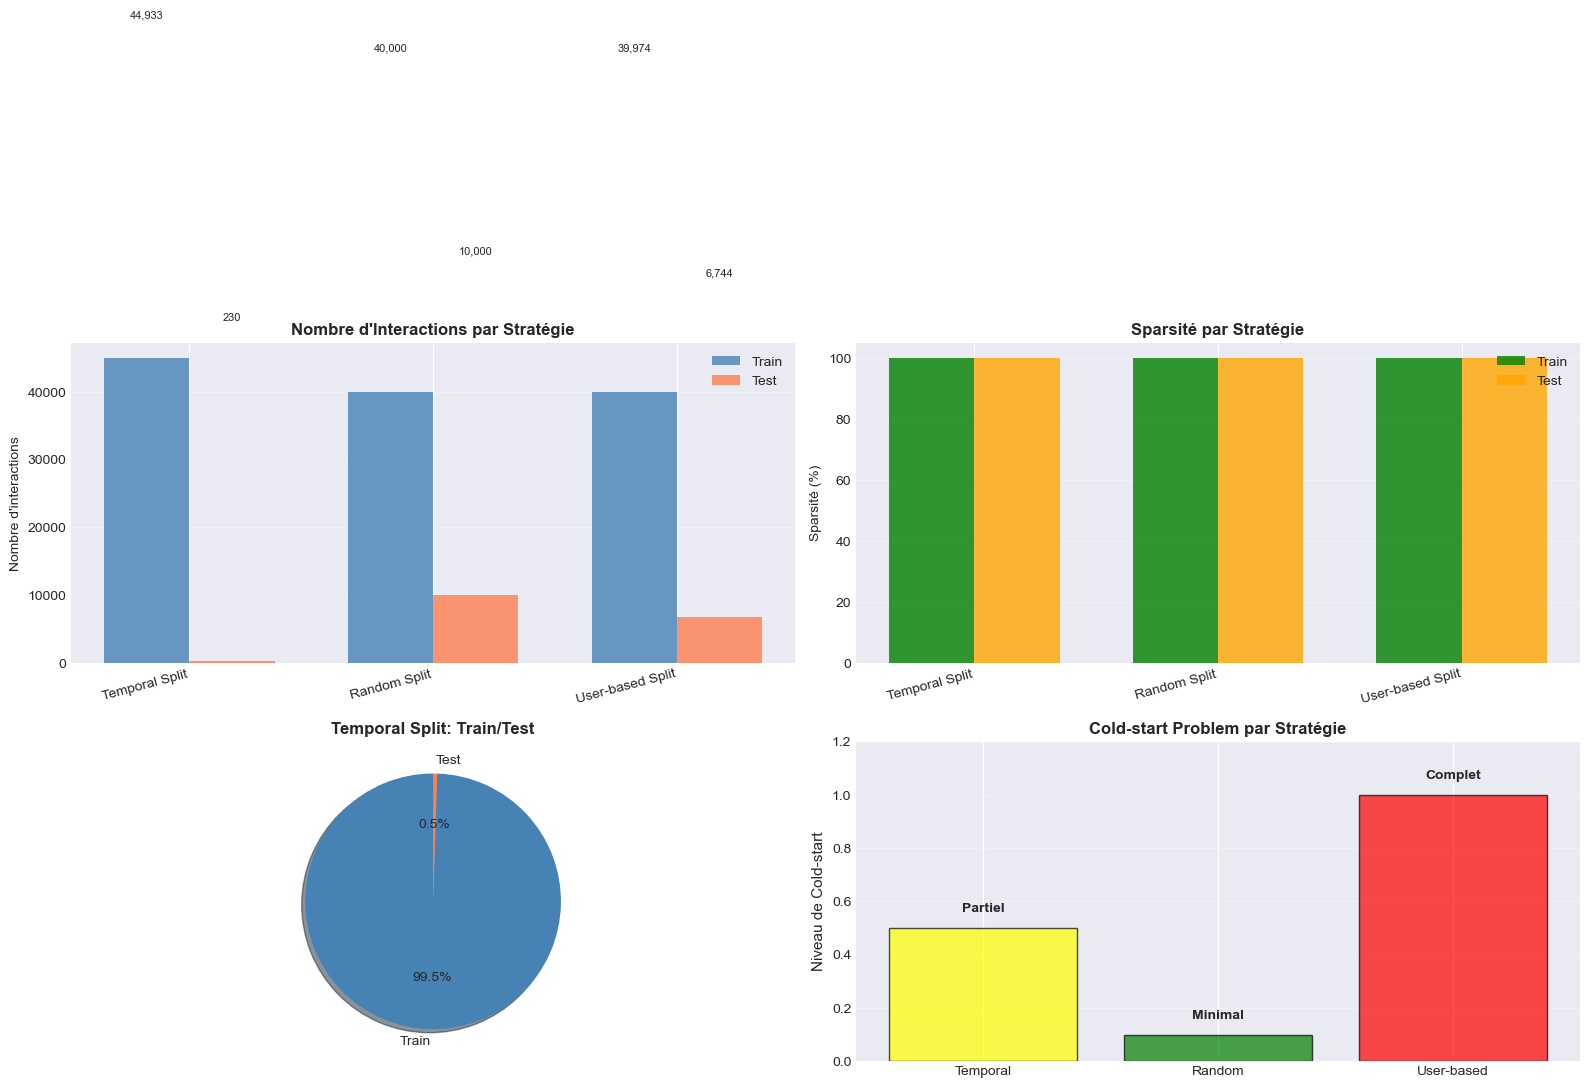


✅ Comparaison visualisée


In [8]:
print("=" * 80)
print("COMPARAISON DES 3 STRATÉGIES")
print("=" * 80)

# Créer un DataFrame de comparaison
comparison_data = {
    'Stratégie': ['Temporal Split', 'Random Split', 'User-based Split'],
    'Train_Interactions': [
        temporal_train_interactions.nnz,
        random_train_interactions.nnz,
        userbased_train_interactions.nnz
    ],
    'Test_Interactions': [
        temporal_test_interactions.nnz,
        random_test_interactions.nnz,
        userbased_test_interactions.nnz
    ],
    'Sparsity_Train': [
        temporal_sparsity_train,
        random_sparsity_train,
        userbased_sparsity_train
    ],
    'Sparsity_Test': [
        temporal_sparsity_test,
        random_sparsity_test,
        userbased_sparsity_test
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Calculer pourcentages
comparison_df['Train_%'] = (comparison_df['Train_Interactions'] / full_interactions.nnz * 100).round(1)
comparison_df['Test_%'] = (comparison_df['Test_Interactions'] / full_interactions.nnz * 100).round(1)

print("\n📊 TABLEAU COMPARATIF:\n")
print(comparison_df.to_string(index=False))

# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Nombre d'interactions train/test
strategies = comparison_df['Stratégie']
train_counts = comparison_df['Train_Interactions']
test_counts = comparison_df['Test_Interactions']

x = np.arange(len(strategies))
width = 0.35

axes[0, 0].bar(x - width/2, train_counts, width, label='Train', color='steelblue', alpha=0.8)
axes[0, 0].bar(x + width/2, test_counts, width, label='Test', color='coral', alpha=0.8)
axes[0, 0].set_ylabel('Nombre d\'interactions')
axes[0, 0].set_title('Nombre d\'Interactions par Stratégie', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(strategies, rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Ajouter valeurs sur les barres
for i, (train, test) in enumerate(zip(train_counts, test_counts)):
    axes[0, 0].text(i - width/2, train + 50000, f'{train:,}', ha='center', va='bottom', fontsize=8)
    axes[0, 0].text(i + width/2, test + 50000, f'{test:,}', ha='center', va='bottom', fontsize=8)

# 2. Sparsité
train_sparsities = comparison_df['Sparsity_Train'] * 100
test_sparsities = comparison_df['Sparsity_Test'] * 100

axes[0, 1].bar(x - width/2, train_sparsities, width, label='Train', color='green', alpha=0.8)
axes[0, 1].bar(x + width/2, test_sparsities, width, label='Test', color='orange', alpha=0.8)
axes[0, 1].set_ylabel('Sparsité (%)')
axes[0, 1].set_title('Sparsité par Stratégie', fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(strategies, rotation=15, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Proportion train/test
axes[1, 0].pie(
    [comparison_df.loc[0, 'Train_Interactions'], comparison_df.loc[0, 'Test_Interactions']],
    labels=['Train', 'Test'],
    autopct='%1.1f%%',
    colors=['steelblue', 'coral'],
    startangle=90,
    shadow=True
)
axes[1, 0].set_title('Temporal Split: Train/Test', fontweight='bold')

# 4. Cold-start analysis
cold_start_scores = {
    'Temporal': 'Partiel',
    'Random': 'Minimal',
    'User-based': 'Complet'
}

cold_start_values = {
    'Temporal': 0.5,  # Cold-start partiel
    'Random': 0.1,    # Cold-start minimal
    'User-based': 1.0 # Cold-start complet
}

strategies_short = ['Temporal', 'Random', 'User-based']
cold_vals = [cold_start_values[s] for s in strategies_short]
colors = ['yellow', 'green', 'red']

axes[1, 1].bar(strategies_short, cold_vals, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Niveau de Cold-start', fontsize=11)
axes[1, 1].set_title('Cold-start Problem par Stratégie', fontweight='bold', fontsize=12)
axes[1, 1].set_ylim([0, 1.2])
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Ajouter labels
for i, (strat, val) in enumerate(zip(strategies_short, cold_vals)):
    label = cold_start_scores[strat]
    axes[1, 1].text(i, val + 0.05, label, ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✅ Comparaison visualisée")

## 8. Choix de la Stratégie et Sauvegarde

### 🎯 Recommandation

Basé sur l'analyse comparative, voici notre recommandation :

In [9]:
print("=" * 80)
print("CHOIX DE LA STRATÉGIE")
print("=" * 80)

print("\n📋 ANALYSE DES 3 STRATÉGIES:\n")

print("1️⃣  TEMPORAL SPLIT:")
print("   ✅ Le plus réaliste (simule prédiction du futur)")
print("   ✅ Pas de data leakage temporel")
print("   ✅ Cohérent avec déploiement production")
print("   ⚠️  Cold-start partiel (nouveaux users/items)")
print(f"   📊 Split: {temporal_train_interactions.nnz:,} train / {temporal_test_interactions.nnz:,} test")

print("\n2️⃣  RANDOM SPLIT:")
print("   ✅ Pas de cold-start")
print("   ✅ Distribution équilibrée")
print("   ⚠️  Moins réaliste (data leakage temporel)")
print("   ⚠️  Ne simule pas la prédiction du futur")
print(f"   📊 Split: {random_train_interactions.nnz:,} train / {random_test_interactions.nnz:,} test")

print("\n3️⃣  USER-BASED SPLIT:")
print("   ✅ Simule nouveaux utilisateurs")
print("   ✅ Test de généralisation")
print("   ⚠️  Cold-start complet (très difficile)")
print("   ⚠️  Performances attendues faibles")
print(f"   📊 Split: {userbased_train_interactions.nnz:,} train / {userbased_test_interactions.nnz:,} test")

print("\n" + "=" * 80)
print("🏆 RECOMMANDATION: TEMPORAL SPLIT")
print("=" * 80)

print("\n✅ Justification:")
print("   • Scénario le plus réaliste pour un système de recommandation")
print("   • Simule correctement la prédiction du futur")
print("   • Évite le data leakage temporel")
print("   • Cold-start gérable (filtrage des users/items communs)")
print("   • Cohérent avec les standards de l'industrie")

print("\n📝 Note:")
print("   Random Split peut être utilisé pour le développement/debug rapide")
print("   User-based Split peut être utilisé pour tester la robustesse au cold-start")

print("\n" + "=" * 80)
print(f"💾 SAUVEGARDE DES 3 STRATÉGIES (dans {SPLITS_PATH})")
print("=" * 80)

from scipy.sparse import save_npz

# Créer sous-dossiers pour chaque stratégie
strategies = ['temporal', 'random', 'userbased']
splits_dict = {
    'temporal': (temporal_train_interactions, temporal_test_interactions, temporal_train_data, temporal_test_data_filtered),
    'random': (random_train_interactions, random_test_interactions, None, None),
    'userbased': (userbased_train_interactions, userbased_test_interactions, userbased_train_data, userbased_test_data_filtered)
}

for strategy_name in strategies:
    strategy_path = SPLITS_PATH + strategy_name + '/'
    os.makedirs(strategy_path, exist_ok=True)

    train_inter, test_inter, train_df, test_df = splits_dict[strategy_name]

    print(f"\n📁 {strategy_name.upper()}:")

    # Sauvegarder matrices
    save_npz(strategy_path + 'train_interactions.npz', train_inter)
    save_npz(strategy_path + 'test_interactions.npz', test_inter)
    print(f"   ✓ train_interactions.npz ({train_inter.nnz:,} interactions)")
    print(f"   ✓ test_interactions.npz ({test_inter.nnz:,} interactions)")

    # Sauvegarder DataFrames (si disponibles)
    if train_df is not None:
        train_df.to_csv(strategy_path + 'train_data.csv', index=False)
        test_df.to_csv(strategy_path + 'test_data.csv', index=False)
        print(f"   ✓ train_data.csv")
        print(f"   ✓ test_data.csv")

# Sauvegarder métadonnées du split temporel (choix principal)
split_metadata = {
    'split_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'sample_size': SAMPLE_SIZE,
    'chosen_strategy': 'Temporal Split',
    'train_ratio': TRAIN_RATIO,
    'cutoff_date': cutoff_date.strftime('%Y-%m-%d'),
    'temporal': {
        'train': {
            'n_interactions': int(temporal_train_interactions.nnz),
            'n_users': len(train_users),
            'n_items': len(train_items),
            'sparsity': float(temporal_sparsity_train),
            'period': {
                'start': temporal_train_data['t_dat'].min().strftime('%Y-%m-%d'),
                'end': temporal_train_data['t_dat'].max().strftime('%Y-%m-%d')
            }
        },
        'test': {
            'n_interactions': int(temporal_test_interactions.nnz),
            'n_users': len(common_users),
            'n_items': len(common_items),
            'sparsity': float(temporal_sparsity_test),
            'period': {
                'start': temporal_test_data_filtered['t_dat'].min().strftime('%Y-%m-%d'),
                'end': temporal_test_data_filtered['t_dat'].max().strftime('%Y-%m-%d')
            }
        },
        'cold_start': {
            'users_common_pct': float(len(common_users) / len(test_users) * 100),
            'items_common_pct': float(len(common_items) / len(test_items) * 100)
        }
    },
    'random': {
        'train_interactions': int(random_train_interactions.nnz),
        'test_interactions': int(random_test_interactions.nnz)
    },
    'userbased': {
        'train_interactions': int(userbased_train_interactions.nnz),
        'test_interactions': int(userbased_test_interactions.nnz),
        'train_users': len(userbased_train_users),
        'test_users': len(userbased_test_users)
    }
}

with open(SPLITS_PATH + 'split_metadata.json', 'w') as f:
    json.dump(split_metadata, f, indent=2)

print(f"\n✓ Métadonnées globales sauvegardées")
print(f"   • split_metadata.json")

print("\n" + "=" * 80)
print("✅ STEP 4 TERMINÉ")
print("=" * 80)

print(f"\n📦 Structure créée dans {SPLITS_PATH}:")
print(f"""
├── temporal/
│   ├── train_interactions.npz
│   ├── test_interactions.npz
│   ├── train_data.csv
│   └── test_data.csv
├── random/
│   ├── train_interactions.npz
│   └── test_interactions.npz
├── userbased/
│   ├── train_interactions.npz
│   ├── test_interactions.npz
│   ├── train_data.csv
│   └── test_data.csv
└── split_metadata.json
""")

print(f"\n🎯 Stratégie recommandée : TEMPORAL")
print(f"   Utiliser : {SPLITS_PATH}temporal/ pour Step 5")

print(f"\n🚀 Prochaine étape: Step 5 - Baseline Models (avec {SAMPLE_SIZE})")

CHOIX DE LA STRATÉGIE

📋 ANALYSE DES 3 STRATÉGIES:

1️⃣  TEMPORAL SPLIT:
   ✅ Le plus réaliste (simule prédiction du futur)
   ✅ Pas de data leakage temporel
   ✅ Cohérent avec déploiement production
   ⚠️  Cold-start partiel (nouveaux users/items)
   📊 Split: 44,933 train / 230 test

2️⃣  RANDOM SPLIT:
   ✅ Pas de cold-start
   ✅ Distribution équilibrée
   ⚠️  Moins réaliste (data leakage temporel)
   ⚠️  Ne simule pas la prédiction du futur
   📊 Split: 40,000 train / 10,000 test

3️⃣  USER-BASED SPLIT:
   ✅ Simule nouveaux utilisateurs
   ✅ Test de généralisation
   ⚠️  Cold-start complet (très difficile)
   ⚠️  Performances attendues faibles
   📊 Split: 39,974 train / 6,744 test

🏆 RECOMMANDATION: TEMPORAL SPLIT

✅ Justification:
   • Scénario le plus réaliste pour un système de recommandation
   • Simule correctement la prédiction du futur
   • Évite le data leakage temporel
   • Cold-start gérable (filtrage des users/items communs)
   • Cohérent avec les standards de l'industrie

